In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import (KFold , StratifiedKFold , cross_val_score,cross_validate,learning_curve)

In [5]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [7]:
url="https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df=pd.read_csv(url)

In [8]:
df['Age']        = df['Age'].fillna(df['Age'].median())
df['Embarked']   = df['Embarked'].fillna('S')
df['Sex']        = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked']   = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone']    = (df['FamilySize'] == 1).astype(int)
df['HasCabin']   = df['Cabin'].notna().astype(int)
df['Title']      = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df['Title']      = df['Title'].replace(
    ['Lady','Countess','Capt','Col','Don','Dr',
     'Major','Rev','Sir','Jonkheer','Dona'], 'Rare'
)
df['Title'] = df['Title'].replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})
df['Title'] = df['Title'].map(
    {'Mr':0,'Miss':1,'Mrs':2,'Master':3,'Rare':4}
).fillna(0)


In [9]:
features=['Pclass','Sex','Age','Fare','Embarked','FamilySize','IsAlone','HasCabin','Title']
X=df[features].values
y=df['Survived'].values

In [10]:
from re import VERBOSE
model=XGBClassifier(n_estimators=100 , max_depth=4 , learning_rate=0.1 , random_state=42 , eval_metric='logloss' , verbosity=0)


In [13]:
###KFold Vs Stratified
kf=KFold(n_splits=5 , shuffle=True , random_state=42)
skf=StratifiedKFold(n_splits=5 , shuffle=True , random_state=42)
kf_scores=cross_val_score(model , X,y,cv=kf)
skf_scores=cross_val_score(model , X, y ,cv=skf)

In [17]:
print("KFScores:",kf_scores)
print(f"KFmean: {kf_scores.mean():.4f}±{kf_scores.std():.4f}")
print("SKFScores:",skf_scores)
print(f"SKFmean: {skf_scores.mean():.4f}±{skf_scores.std():.4f}")

KFScores: [0.84357542 0.84831461 0.86516854 0.79775281 0.82022472]
KFmean: 0.8350±0.0235
SKFScores: [0.8547486  0.85955056 0.81460674 0.8258427  0.83146067]
SKFmean: 0.8372±0.0172


In [18]:
cv_results = cross_validate(
    model, X, y,
    cv=skf,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    return_train_score=True
)

print("\n--- Cross-validation results ---")
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    test_scores  = cv_results[f'test_{metric}']
    train_scores = cv_results[f'train_{metric}']
    print(f"{metric:<12} train: {train_scores.mean():.4f} "
          f"| test: {test_scores.mean():.4f} "
          f"| gap: {(train_scores.mean()-test_scores.mean()):.4f}")


--- Cross-validation results ---
accuracy     train: 0.9111 | test: 0.8372 | gap: 0.0738
precision    train: 0.9229 | test: 0.8174 | gap: 0.1055
recall       train: 0.8384 | test: 0.7426 | gap: 0.0958
f1           train: 0.8785 | test: 0.7778 | gap: 0.1008
roc_auc      train: 0.9644 | test: 0.8751 | gap: 0.0894


KFold scores:             [0.8436 0.8483 0.8652 0.7978 0.8202]
KFold mean:              0.8350 ± 0.0235

StratifiedKFold scores:   [0.8547 0.8596 0.8146 0.8258 0.8315]
StratifiedKFold mean:    0.8372 ± 0.0172

--- Cross-validation results ---
accuracy     train: 0.9111 | test: 0.8372 | gap: 0.0738
precision    train: 0.9229 | test: 0.8174 | gap: 0.1055
recall       train: 0.8384 | test: 0.7426 | gap: 0.0958
f1           train: 0.8785 | test: 0.7778 | gap: 0.1008
roc_auc      train: 0.9644 | test: 0.8751 | gap: 0.0894


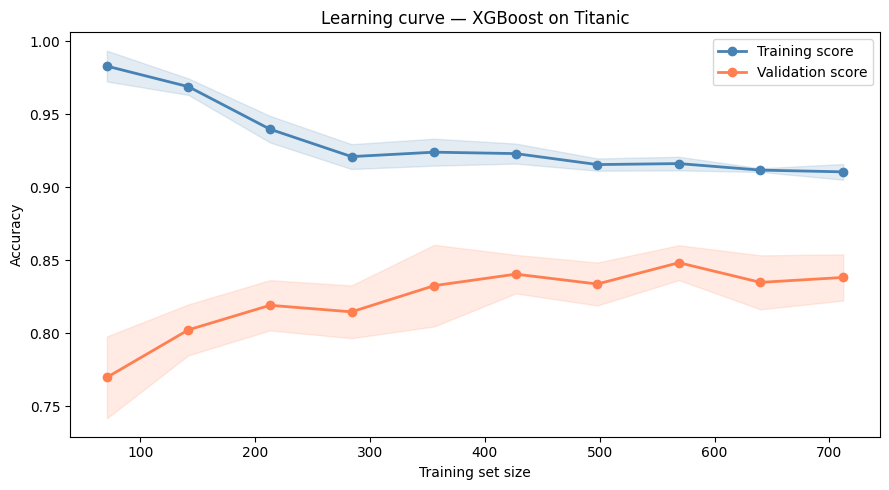

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import (
    KFold, StratifiedKFold, cross_val_score,
    cross_validate, learning_curve
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Load + prep Titanic (familiar by now)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df  = pd.read_csv(url)

df['Age']        = df['Age'].fillna(df['Age'].median())
df['Embarked']   = df['Embarked'].fillna('S')
df['Sex']        = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked']   = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone']    = (df['FamilySize'] == 1).astype(int)
df['HasCabin']   = df['Cabin'].notna().astype(int)
df['Title']      = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df['Title']      = df['Title'].replace(
    ['Lady','Countess','Capt','Col','Don','Dr',
     'Major','Rev','Sir','Jonkheer','Dona'], 'Rare'
)
df['Title'] = df['Title'].replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})
df['Title'] = df['Title'].map(
    {'Mr':0,'Miss':1,'Mrs':2,'Master':3,'Rare':4}
).fillna(0)

features = ['Pclass','Sex','Age','Fare','Embarked',
            'FamilySize','IsAlone','HasCabin','Title']
X = df[features].values
y = df['Survived'].values

model = XGBClassifier(n_estimators=100, max_depth=4,
                      learning_rate=0.1, random_state=42,
                      eval_metric='logloss', verbosity=0)

# -----------------------------------------------
# 1. KFold vs StratifiedKFold — what's the difference?
# -----------------------------------------------
kf  = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

kf_scores  = cross_val_score(model, X, y, cv=kf,  scoring='accuracy')
skf_scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')

print("KFold scores:            ", kf_scores.round(4))
print(f"KFold mean:              {kf_scores.mean():.4f} ± {kf_scores.std():.4f}")
print("\nStratifiedKFold scores:  ", skf_scores.round(4))
print(f"StratifiedKFold mean:    {skf_scores.mean():.4f} ± {skf_scores.std():.4f}")
# StratifiedKFold preserves class ratio in each fold
# Always use StratifiedKFold for classification

# -----------------------------------------------
# 2. Cross_validate — get multiple metrics at once
# -----------------------------------------------
cv_results = cross_validate(
    model, X, y,
    cv=skf,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    return_train_score=True
)

print("\n--- Cross-validation results ---")
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    test_scores  = cv_results[f'test_{metric}']
    train_scores = cv_results[f'train_{metric}']
    print(f"{metric:<12} train: {train_scores.mean():.4f} "
          f"| test: {test_scores.mean():.4f} "
          f"| gap: {(train_scores.mean()-test_scores.mean()):.4f}")
# Large gap between train and test = overfitting

# -----------------------------------------------
# 3. Learning curve — diagnose under/overfitting
# -----------------------------------------------
train_sizes, train_scores, val_scores = learning_curve(
    model, X, y,
    cv=skf,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue',
         label='Training score',   linewidth=2)
plt.plot(train_sizes, val_mean,   'o-', color='coral',
         label='Validation score', linewidth=2)
plt.fill_between(train_sizes,
                 train_mean - train_std,
                 train_mean + train_std, alpha=0.15, color='steelblue')
plt.fill_between(train_sizes,
                 val_mean - val_std,
                 val_mean + val_std, alpha=0.15, color='coral')
plt.xlabel('Training set size')
plt.ylabel('Accuracy')
plt.title('Learning curve — XGBoost on Titanic')
plt.legend()
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150)
plt.show()

# If train >> val: overfitting (need more data or regularisation)
# If both low: underfitting (need more complex model or features)